# `find_and_suppress` on MIDOG++ -- rot90 augmentation, raw RGB

**Purpose.** A third point on the augmentation-footprint axis from
`Research Logs/design_choices.md`, section 4, run with the other two simplifications
already adopted as pipeline defaults:

- **8-template augmentation bank** -- 4 rotations (0/90/180/270) x 2 flips, i.e.
  `experiment.AUGMENTATION_VARIANTS`'s `rot90_4angles_2flips` entry. Neither the
  24-template default from the first notebook
  ([`find_and_suppress_midog.ipynb`](find_and_suppress_midog.ipynb)) nor the
  single-template default from the simplest-configuration notebook
  ([`find_and_suppress_midog_simple.ipynb`](find_and_suppress_midog_simple.ipynb)) --
  a midpoint chosen because it is the only variant in that section's own single-seed
  measurement that outscored both on `discrimination` (0.068 vs 0.037 and -0.034).
- **no multi-scale** -- one template size (the tightened box's own native size),
  `FSConfig`'s own default.
- **raw RGB template** -- no grayscale conversion, no inversion; the match runs
  directly on the 3-channel crop, same as the simplest-configuration notebook.
- **binary Otsu for bbox tightening** -- `seed_selection.tighten_box_otsu`'s default.
  The multi-otsu comparison in `Research Logs/design_choices.md` section 7/7a is a
  separate, still-open piece of work; this notebook does not touch it and does not pass
  `bbox_method="multiotsu"` anywhere.

Same seven ROIs (one per tumour domain) and the same `seed=0` scheme as the other two
notebooks -- `experiment.run_experiment` builds each image's RNG from `(seed, image_id)`
alone, so this reproduces the identical seed annotation and tightened template size per
image as both siblings, per section 4's own instruction: "compare variants using the same
seed per image ... so the comparison isolates augmentation count." Only the augmentation
count and the channel differ from the simplest-configuration notebook.

All logic lives in [`midog_utils/`](midog_utils/); this notebook only calls it.

**Environment.** `requirements-midog-utils.txt`, *not* `requirements.txt` -- nothing here
imports fastai or SlideRunner. The pin that matters is `numpy < 2`: the opencv wheel in
use was built against the numpy 1.x C API, so under numpy 2.x both `import cv2` and
`tifffile`'s LZW path (needed for the pyramidal 505/506) fail.


In [1]:
import sys, time
sys.path.insert(0, '..') if 'midog_utils' not in __import__('os').listdir('.') else None

import numpy as np, pandas as pd, matplotlib.pyplot as plt

from midog_utils import dataset as ds, channels as ch, template_match as tm
from midog_utils import find_and_suppress as fs, evaluate as ev, experiment as ex, viz

pd.set_option('display.width', 200); pd.set_option('display.max_columns', 60)

images, annotations = ds.load_annotations('databases/MIDOG++.json')
ds.check_invariants(annotations)          # every bbox is 50x50 and TLBR, or this raises
print(f'{len(images)} annotated images, {len(annotations)} annotations')


503 annotated images, 26286 annotations


## Which images

Same rule as both other notebooks: one ROI per tumour domain, the downloaded image with
the most mitotic figures (ties to the lower id). See
[`find_and_suppress_midog.ipynb`](find_and_suppress_midog.ipynb) for why this is an
optimistic selection rather than a representative one -- unchanged here, since the point
of this notebook is the augmentation-footprint axis, not the image-selection rule.


In [2]:
selection = ex.select_domain_images(images, annotations)
selection[['image_id', 'file_name', 'tumor_type', 'n_mitotic']]


,image_id,file_name,tumor_type,n_mitotic
0,301,301.tiff,canine cutaneous mast cell tumor,218
1,201,201.tiff,canine lung cancer,18
2,246,246.tiff,canine lymphosarcoma,116
3,405,405.tiff,canine soft tissue sarcoma,14
4,2,002.tiff,human breast cancer,9
5,506,506.tiff,human melanoma,12
6,350,350.tiff,human neuroendocrine tumor,4


## Configuration

Two overrides from `FSConfig()`'s own defaults: `channel='rgb'` (raw RGB, no grayscale
inversion) and `n_angles=4, flips=(False, True)` (4 rotations x 2 flips = 8 templates).
`scales` stays at the single-scale default, and `bbox_method` is left at
`run_one_image`'s default (`"binary"`) throughout -- the multi-otsu variant is a
separate, still-open comparison this notebook does not run.


In [3]:
cfg = fs.FSConfig(channel='rgb', n_angles=4, flips=(False, True))
print(cfg)
print(f'\n{cfg.n_augmentations} augmentations per run '
      f'({cfg.n_angles} rotations x {len(cfg.flips)} flips x {len(cfg.scales)} scale)')


FSConfig(channel='rgb', base_size=51, patch_size=73, scales=(1.0,), n_angles=4, flips=(False, True), peak_min_distance=7, score_threshold=0.5, max_peaks=250000, nms_radius=None, self_hit_radius=5.0, max_detections=1000000000, scale_normalize=False)

8 augmentations per run (4 rotations x 2 flips x 1 scale)


## Run

8 augmentations (4 rotations x 2 flips x 1 scale) correlated per image, plus the
nucleus-blob and random-in-tissue baselines -- an eighth of the first notebook's
24-template bank, eight times the simplest-configuration notebook's single template.


In [4]:
t0 = time.time()
results, metrics, detections = ex.run_experiment(selection, annotations, cfg=cfg, seed=0)
print(f'\ntotal {time.time()-t0:.0f}s')

metrics.to_csv('results/fs_rot90_rgb_metrics.csv', index=False)
detections.to_csv('results/fs_rot90_rgb_detections.csv', index=False)


=== 301.tiff  (canine cutaneous mast cell tumor, 218 mitotic) 
    recall@K=0.332  attraction@K=0.138  coverage=0.93  (72s)
=== 201.tiff  (canine lung cancer, 18 mitotic) 
    recall@K=0.059  attraction@K=0.061  coverage=0.08  (112s)
=== 246.tiff  (canine lymphosarcoma, 116 mitotic) 
    recall@K=0.148  attraction@K=0.024  coverage=0.00  (75s)
=== 405.tiff  (canine soft tissue sarcoma, 14 mitotic) 
    recall@K=0.000  attraction@K=0.000  coverage=0.58  (67s)
=== 002.tiff  (human breast cancer, 9 mitotic) 
    recall@K=0.000  attraction@K=0.000  coverage=0.55  (64s)
=== 506.tiff  (human melanoma, 12 mitotic) 
    recall@K=0.000  attraction@K=0.000  coverage=0.40  (56s)
=== 350.tiff  (human neuroendocrine tumor, 4 mitotic) 
    recall@K=0.000  attraction@K=0.000  coverage=0.51  (174s)

total 620s


## Results

### Headline: `recall@K`

`K` = the number of mitotic figures in that ROI, minus the seed -- see the first
notebook's discussion of why this is the threshold-free headline number. Read
`coverage_frac` alongside it, per image, before trusting a full-list number anywhere
below.


In [5]:
ex.summary_table(metrics)


,tumor_type,file_name,method,n_gt_mitotic_eval,n_lookalike_gt,recall_at_k,lookalike_attraction_at_k,topk_tp,topk_fp_lookalike,topk_fp_unannotated,sens@8fp_mm2,sens@64fp_mm2,n_unanimous,recall_unanimous_at_k,n_contested,recall_contested_at_k,max_detection_score,n_detections_total
0,canine cutaneous mast cell tumor,301.tiff,find_and_suppress,217,109,0.331797,0.137615,72,15,130,0.156682,0.327189,163,0.361963,54,0.240741,0.921829,16766
1,canine lung cancer,201.tiff,find_and_suppress,17,49,0.058824,0.061224,1,3,13,0.000000,0.294118,6,0.166667,11,0.000000,0.635876,925
2,canine lymphosarcoma,246.tiff,find_and_suppress,115,123,0.147826,0.024390,17,3,20,0.139130,0.147826,99,0.171717,16,0.000000,0.598671,40
3,canine soft tissue sarcoma,405.tiff,find_and_suppress,13,19,0.000000,0.000000,0,0,13,0.000000,0.153846,9,0.000000,4,0.000000,0.828673,7323
4,human breast cancer,002.tiff,find_and_suppress,8,7,0.000000,0.000000,0,0,8,0.000000,0.375000,6,0.000000,2,0.000000,0.849936,7430
5,human melanoma,506.tiff,find_and_suppress,11,12,0.000000,0.000000,0,0,11,0.000000,0.181818,7,0.000000,4,0.000000,0.771363,5326
6,human neuroendocrine tumor,350.tiff,find_and_suppress,3,16,0.000000,0.000000,0,0,3,0.000000,0.333333,0,NaN,3,0.000000,0.780449,6904


### Against the baselines

`nucleus_blobs` (any dark blob, hematoxylin channel) and `random_in_tissue` (the floor).
If 8-template, raw-RGB matching does not beat the blob detector at an equal budget, that
is the finding for this configuration.


In [6]:
pivot = metrics.pivot_table(index=['tumor_type', 'file_name'], columns='method',
                            values='recall_at_k').round(3)
pivot['lift_vs_blobs'] = (pivot['find_and_suppress'] /
                          pivot['nucleus_blobs'].replace(0, np.nan)).round(2)
pivot


,method,find_and_suppress,nucleus_blobs,random_in_tissue,lift_vs_blobs
tumor_type,file_name,,,,
canine cutaneous mast cell tumor,301.tiff,0.332,0.594,0.023,0.56
canine lung cancer,201.tiff,0.059,0.235,0.000,0.25
canine lymphosarcoma,246.tiff,0.148,0.330,0.000,0.45
canine soft tissue sarcoma,405.tiff,0.000,0.000,0.000,NaN
human breast cancer,002.tiff,0.000,0.000,0.000,NaN
human melanoma,506.tiff,0.000,0.000,0.000,NaN
human neuroendocrine tumor,350.tiff,0.000,0.000,0.000,NaN


### Every detection, not just the top K

Bucketed by what it landed on, with no top-K budget. `coverage_frac` first, as always --
see `evaluate.py`'s module docstring for why a saturated list makes full-list recall
uninformative.


In [7]:
ex.full_list_table(metrics)


,tumor_type,file_name,all_n_detections,coverage_frac,all_tp,all_fp_lookalike,all_fp_unannotated,all_matched_any_gt,all_matched_frac,all_precision_mitotic,all_mitotic_gt_found,all_mitotic_gt_missed,all_lookalike_gt_found,all_lookalike_gt_missed
0,canine cutaneous mast cell tumor,301.tiff,16766,0.9325,210,103,16453,313,0.018669,0.012525,210,7,103,6
1,canine lung cancer,201.tiff,925,0.0784,12,24,889,36,0.038919,0.012973,12,5,24,25
2,canine lymphosarcoma,246.tiff,40,0.0036,17,3,20,20,0.500000,0.425000,17,98,3,120
3,canine soft tissue sarcoma,405.tiff,7323,0.5778,13,18,7292,31,0.004233,0.001775,13,0,18,1
4,human breast cancer,002.tiff,7430,0.5455,8,6,7416,14,0.001884,0.001077,8,0,6,1
5,human melanoma,506.tiff,5326,0.3993,10,9,5307,19,0.003567,0.001878,10,1,9,3
6,human neuroendocrine tumor,350.tiff,6904,0.5141,3,15,6886,18,0.002607,0.000435,3,0,15,1


### Expert-agreement split

Mitotic recall split by whether every rater who saw the annotation called it mitotic,
budgeted at the same K as everything else.


In [8]:
metrics[metrics.method == 'find_and_suppress'][
    ['tumor_type', 'file_name', 'k', 'tightened_base_size', 'seed_agreement_flagged',
     'n_unanimous', 'recall_unanimous_at_k', 'n_contested', 'recall_contested_at_k']
].sort_values('tumor_type').reset_index(drop=True)


,tumor_type,file_name,k,tightened_base_size,seed_agreement_flagged,n_unanimous,recall_unanimous_at_k,n_contested,recall_contested_at_k
0,canine cutaneous mast cell tumor,301.tiff,217,35.0,False,163,0.361963,54,0.240741
1,canine lung cancer,201.tiff,17,51.0,False,6,0.166667,11,0.000000
2,canine lymphosarcoma,246.tiff,115,51.0,False,99,0.171717,16,0.000000
3,canine soft tissue sarcoma,405.tiff,13,51.0,False,9,0.000000,4,0.000000
4,human breast cancer,002.tiff,8,35.0,False,6,0.000000,2,0.000000
5,human melanoma,506.tiff,11,43.0,False,7,0.000000,4,0.000000
6,human neuroendocrine tumor,350.tiff,3,41.0,True,0,NaN,3,0.000000


### FROC

Sensitivity against false positives per mm^2, this configuration only (no baseline
overlay -- see the pivot table above for the equal-budget baseline comparison).


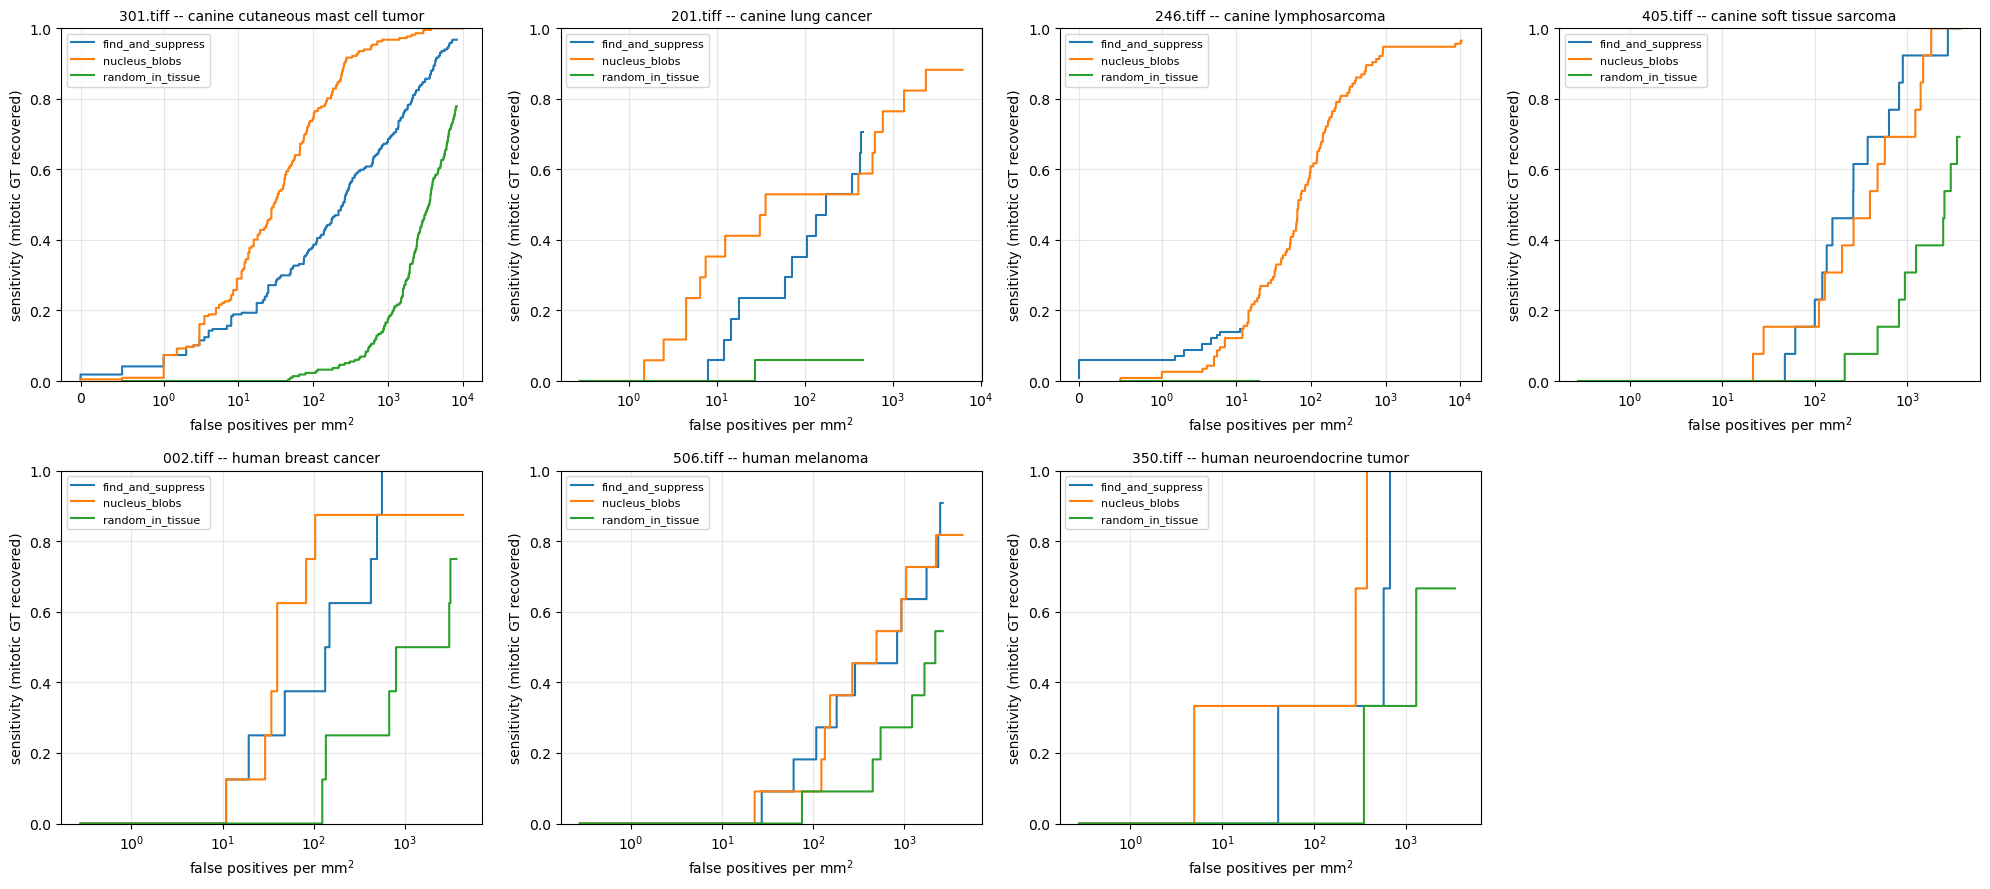

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, (fn, res) in zip(axes.ravel(), results.items()):
    curves = [('find_and_suppress', *res['curve'])]
    if 'baseline_blobs_curve' in res:
        curves.append(('nucleus_blobs', *res['baseline_blobs_curve']))
        curves.append(('random_in_tissue', *res['baseline_random_curve']))
    tumor = selection.loc[selection.file_name == fn, 'tumor_type'].iloc[0]
    viz.froc_plot(curves, ax=ax, title=f'{fn} -- {tumor}')
for ax in axes.ravel()[len(results):]:
    ax.axis('off')
fig.tight_layout(); plt.show()


### Where the detections land

White star = the seed. Red = ground-truth mitotic figures, yellow = ground-truth
look-alikes. Detections are the top-K only, coloured by bucket, drawn at the match
radius.


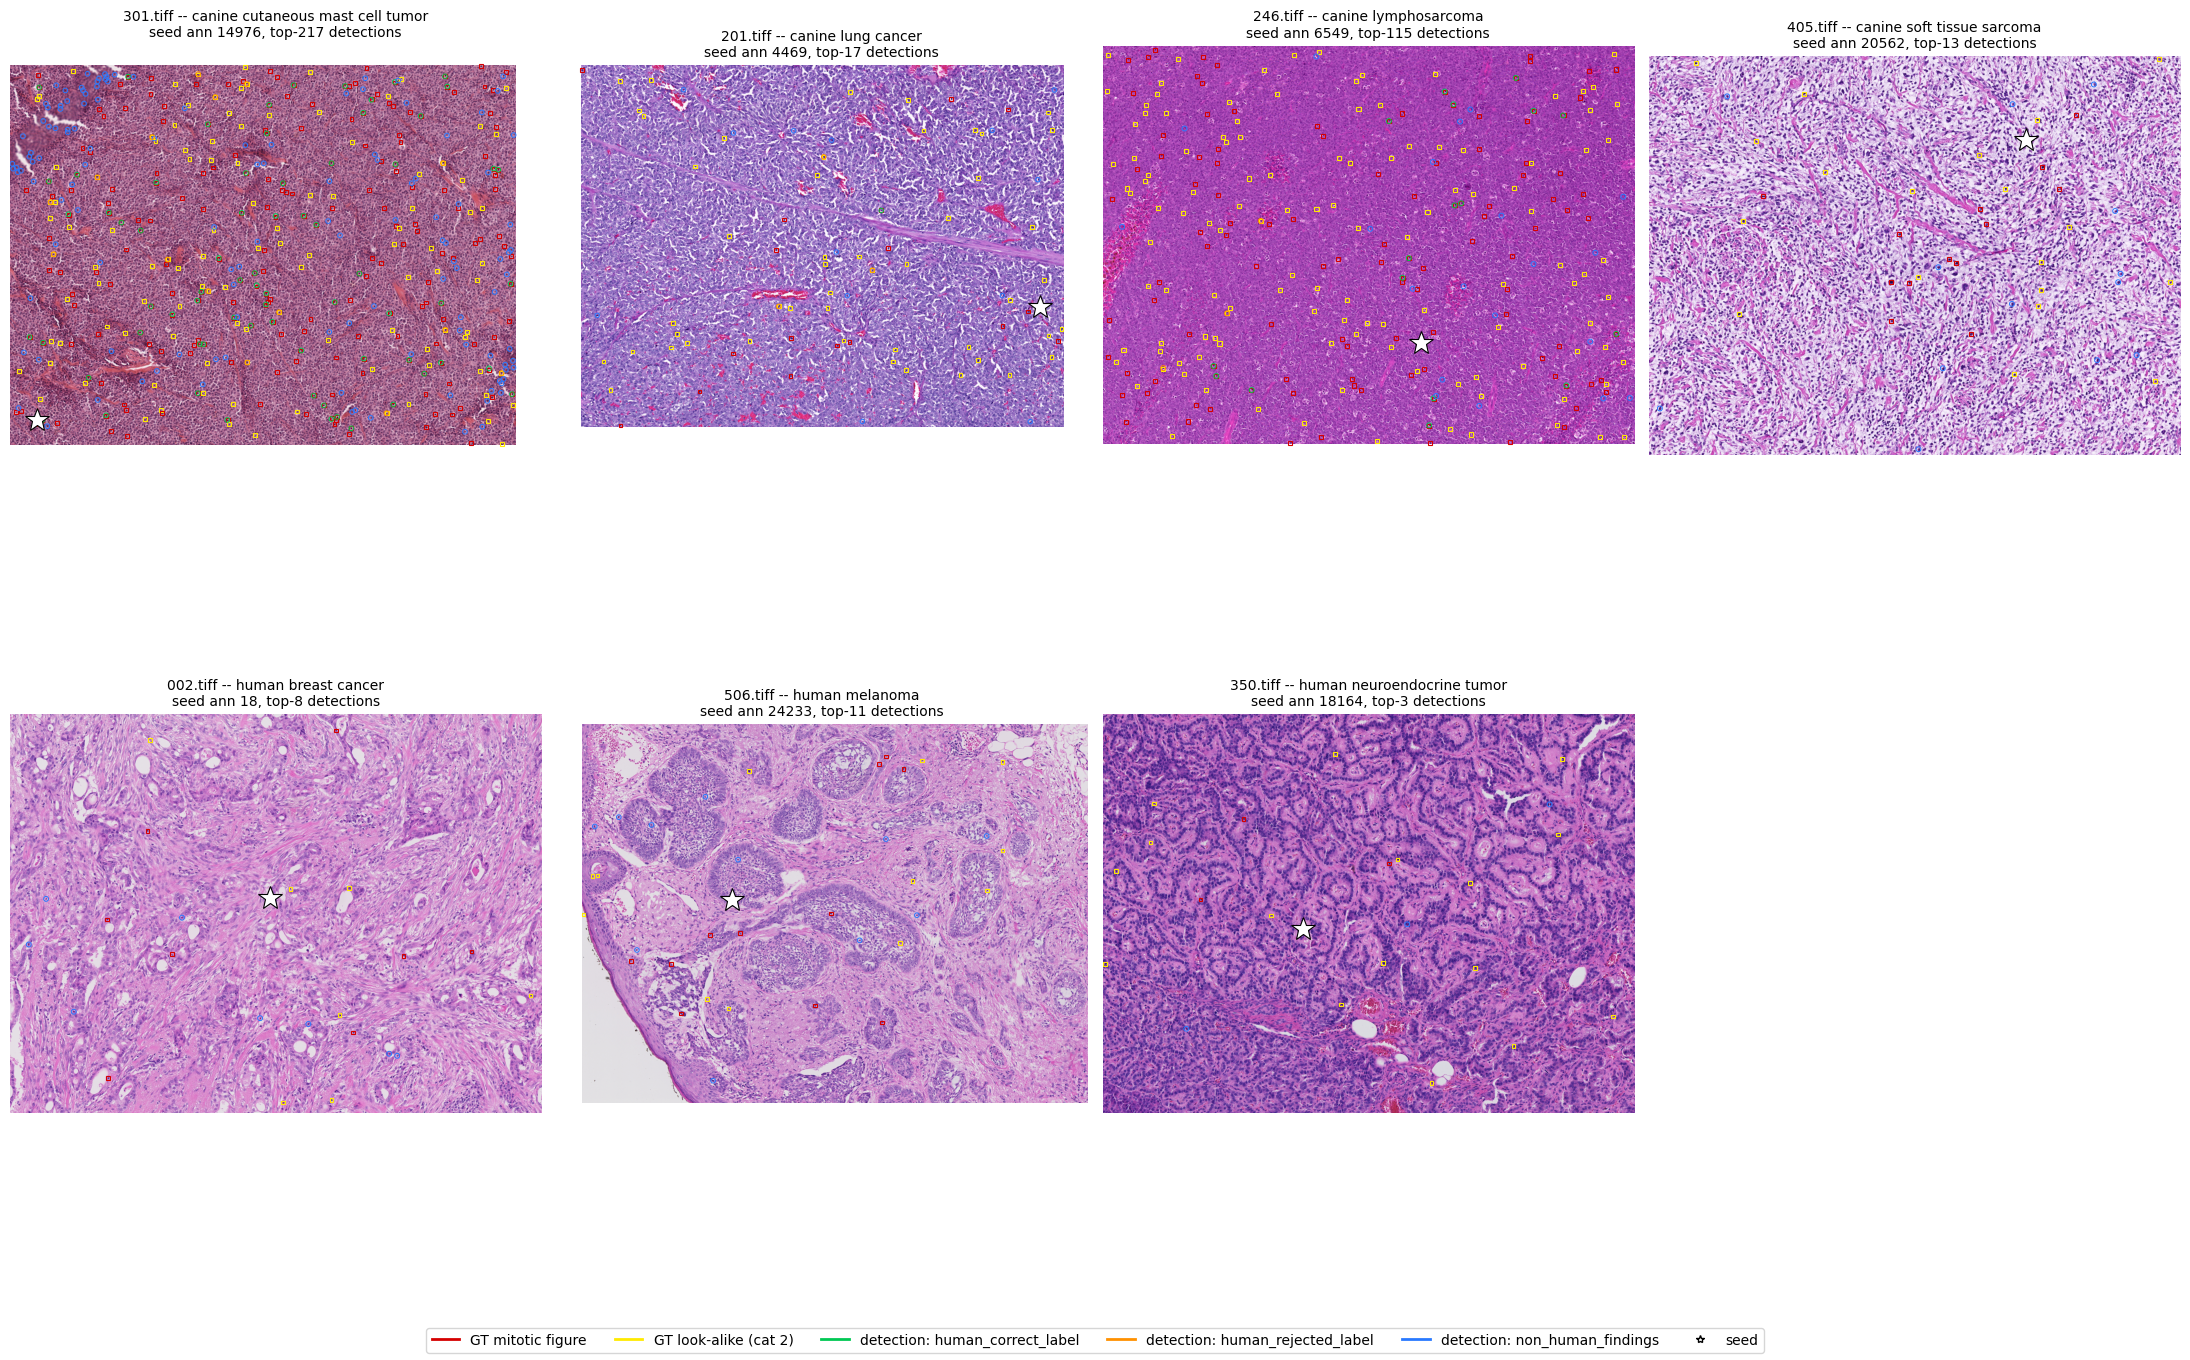

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(22, 15))
for ax, (fn, res) in zip(axes.ravel(), results.items()):
    rgb = ds.load_roi(f'images/{fn}')
    k = res['metrics'][0]['k']
    tumor = selection.loc[selection.file_name == fn, 'tumor_type'].iloc[0]
    viz.overlay(rgb, res['gt'], res['detections'], (res['seed'].cx, res['seed'].cy),
                ax=ax, downsample=4, top_n=k, radius=res['radius'],
                title=f"{fn} -- {tumor}\nseed ann {int(res['seed'].ann_id)}, top-{k} detections")
    del rgb
for ax in axes.ravel()[len(results):]:
    ax.axis('off')
fig.legend(handles=viz.legend_handles(), loc='lower center', ncol=6, fontsize=10)
fig.tight_layout(rect=(0, 0.03, 1, 1)); plt.show()


## Channel comparison: hematoxylin and `gray_inverted`

Same 8-template augmentation bank (4 rotations x 2 flips, single scale) as the run
above, changing only `FSConfig.channel`: `hematoxylin` (colour-deconvolved,
chromatin-selective) and `gray_inverted` (`255 - grayscale`, the channel the *first*
notebook used with its 24-template bank). `raw RGB` is the run already done above --
this section adds the other two of the three search-channel variants from
`Research Logs/design_choices.md`, section 3.

**Why this is a clean channel-only ablation.** `experiment.run_experiment` builds each
image's RNG from `(seed, image_id)` alone, and seed selection itself
(`seed_selection.pick_seed` / `tightened_base_size`) always runs on the `gray_inverted`
structural channel regardless of `FSConfig.channel` -- so calling `run_experiment(...,
seed=0)` again with only `channel` (and the same `n_angles`/`flips` overrides) changed
reproduces the exact same seed annotation and tightened template size per image as the
RGB run above. Confirmed below rather than assumed.

**Baselines are not re-run.** `nucleus_blobs` and `random_in_tissue` don't depend on
`FSConfig.channel` -- rerunning them here would reproduce the RGB run's baseline rows
exactly, at the cost of the same per-image baseline time again.


In [11]:
cfg_hematoxylin = fs.FSConfig(channel='hematoxylin', n_angles=4, flips=(False, True))
t0 = time.time()
results_hem, metrics_hem, detections_hem = ex.run_experiment(
    selection, annotations, cfg=cfg_hematoxylin, seed=0, run_baselines=False)
print(f'\ntotal {time.time()-t0:.0f}s')

metrics_hem.to_csv('results/fs_rot90_hematoxylin_metrics.csv', index=False)
detections_hem.to_csv('results/fs_rot90_hematoxylin_detections.csv', index=False)


=== 301.tiff  (canine cutaneous mast cell tumor, 218 mitotic) 
    recall@K=0.290  attraction@K=0.101  coverage=0.94  (24s)
=== 201.tiff  (canine lung cancer, 18 mitotic) 
    recall@K=0.059  attraction@K=0.102  coverage=0.21  (24s)
=== 246.tiff  (canine lymphosarcoma, 116 mitotic) 
    recall@K=0.400  attraction@K=0.057  coverage=0.01  (26s)
=== 405.tiff  (canine soft tissue sarcoma, 14 mitotic) 
    recall@K=0.000  attraction@K=0.053  coverage=0.60  (34s)
=== 002.tiff  (human breast cancer, 9 mitotic) 
    recall@K=0.000  attraction@K=0.000  coverage=0.59  (61s)
=== 506.tiff  (human melanoma, 12 mitotic) 
    recall@K=0.000  attraction@K=0.000  coverage=0.51  (45s)
=== 350.tiff  (human neuroendocrine tumor, 4 mitotic) 
    recall@K=0.000  attraction@K=0.062  coverage=0.62  (30s)

total 244s


In [12]:
cfg_gray_inverted = fs.FSConfig(channel='gray_inverted', n_angles=4, flips=(False, True))
t0 = time.time()
results_gray, metrics_gray, detections_gray = ex.run_experiment(
    selection, annotations, cfg=cfg_gray_inverted, seed=0, run_baselines=False)
print(f'\ntotal {time.time()-t0:.0f}s')

metrics_gray.to_csv('results/fs_rot90_gray_inverted_metrics.csv', index=False)
detections_gray.to_csv('results/fs_rot90_gray_inverted_detections.csv', index=False)


=== 301.tiff  (canine cutaneous mast cell tumor, 218 mitotic) 
    recall@K=0.304  attraction@K=0.101  coverage=0.94  (32s)
=== 201.tiff  (canine lung cancer, 18 mitotic) 
    recall@K=0.059  attraction@K=0.020  coverage=0.13  (70s)
=== 246.tiff  (canine lymphosarcoma, 116 mitotic) 
    recall@K=0.157  attraction@K=0.057  coverage=0.01  (40s)
=== 405.tiff  (canine soft tissue sarcoma, 14 mitotic) 
    recall@K=0.000  attraction@K=0.000  coverage=0.62  (32s)
=== 002.tiff  (human breast cancer, 9 mitotic) 
    recall@K=0.000  attraction@K=0.000  coverage=0.70  (28s)
=== 506.tiff  (human melanoma, 12 mitotic) 
    recall@K=0.000  attraction@K=0.000  coverage=0.51  (28s)
=== 350.tiff  (human neuroendocrine tumor, 4 mitotic) 
    recall@K=0.000  attraction@K=0.000  coverage=0.64  (27s)

total 257s


### Sanity check: is this actually apples-to-apples?

Before trusting any difference between channels as a channel effect, confirm the three
runs agree on everything that is *supposed* to be identical: which annotation was the
seed, and what size template it was tightened to. Also confirm the three `FSConfig`s
differ in `channel` and nothing else.


In [13]:
from dataclasses import asdict, fields

# 1. cfg objects differ only in `channel`.
cfg_rgb = cfg
diffs = {f.name for f in fields(cfg_rgb)
         if not (asdict(cfg_rgb)[f.name] == asdict(cfg_hematoxylin)[f.name] == asdict(cfg_gray_inverted)[f.name])}
assert diffs == {'channel'}, f'FSConfig fields other than channel differ: {diffs}'
print('OK: the three configs differ only in `channel`.')

# 2. Same seed annotation and same tightened template size, per image, across all three channels.
key_cols = ['file_name', 'seed_ann_id', 'tightened_base_size']
m_rgb = metrics[metrics.method == 'find_and_suppress'][key_cols].set_index('file_name')
m_h = metrics_hem[key_cols].set_index('file_name')
m_g = metrics_gray[key_cols].set_index('file_name')

seed_mismatch = m_rgb.index[(m_rgb.seed_ann_id != m_h.seed_ann_id) | (m_rgb.seed_ann_id != m_g.seed_ann_id)]
size_mismatch = m_rgb.index[(m_rgb.tightened_base_size != m_h.tightened_base_size) |
                            (m_rgb.tightened_base_size != m_g.tightened_base_size)]
assert len(seed_mismatch) == 0, f'seed_ann_id differs by channel on: {list(seed_mismatch)}'
assert len(size_mismatch) == 0, f'tightened_base_size differs by channel on: {list(size_mismatch)}'
print('OK: same seed_ann_id and same tightened_base_size on all 7 images across rgb/hematoxylin/gray_inverted.')

m_rgb.join(m_h, lsuffix='_rgb', rsuffix='_hem').join(m_g.add_suffix('_gray'))


OK: the three configs differ only in `channel`.
OK: same seed_ann_id and same tightened_base_size on all 7 images across rgb/hematoxylin/gray_inverted.


,seed_ann_id_rgb,tightened_base_size_rgb,seed_ann_id_hem,tightened_base_size_hem,seed_ann_id_gray,tightened_base_size_gray
file_name,,,,,,
301.tiff,14976,35.0,14976,35,14976,35
201.tiff,4469,51.0,4469,51,4469,51
246.tiff,6549,51.0,6549,51,6549,51
405.tiff,20562,51.0,20562,51,20562,51
002.tiff,18,35.0,18,35,18,35
506.tiff,24233,43.0,24233,43,24233,43
350.tiff,18164,41.0,18164,41,18164,41


### Headline comparison: `recall@K` by channel

Same `K` and the same seed/template per image across all three columns, so a difference
here is attributable to what the correlation actually searched in, not to a different
draw or a different template size.


In [14]:
combined = pd.concat([
    metrics[metrics.method == 'find_and_suppress'],
    metrics_hem, metrics_gray,
], ignore_index=True)
combined.to_csv('results/fs_rot90_channel_comparison_metrics.csv', index=False)

channel_pivot = combined.pivot_table(
    index=['tumor_type', 'file_name'], columns='channel',
    values=['recall_at_k', 'lookalike_attraction_at_k', 'coverage_frac',
            'n_detections_total', 'max_detection_score']
).round(3)
channel_pivot


coverage_frac                    lookalike_attraction_at_k                    max_detection_score                    n_detections_total              \
channel                                    gray_inverted hematoxylin    rgb             gray_inverted hematoxylin    rgb       gray_inverted hematoxylin    rgb      gray_inverted hematoxylin   
tumor_type                       file_name                                                                                                                                                       
canine cutaneous mast cell tumor 301.tiff          0.939       0.935  0.932                     0.101       0.101  0.138               0.931       0.943  0.922            17030.0     16915.0   
canine lung cancer               201.tiff          0.131       0.205  0.078                     0.020       0.102  0.061               0.639       0.704  0.636             1578.0      2468.0   
canine lymphosarcoma             246.tiff          0.012       0.013  0.004                     0.057       0.057  0.024               0.623       0.615  0.599              142.0       151.0   
canine soft tissue sarcoma       405.tiff          0.619       0.596  0.578                     0.000       0.053  0.000               0.844       0.844  0.829             7946.0      7701.0   
human breast cancer              002.tiff          0.699       0.590  0.546                     0.000       0.000  0.000               0.864       0.883  0.850            10154.0      8244.0   
human melanoma                   506.tiff          0.508       0.508  0.399                     0.000       0.000  0.000               0.795       0.793  0.771             6980.0      7150.0   
human neuroendocrine tumor       350.tiff          0.638       0.622  0.514                     0.000       0.062  0.000               0.827       0.837  0.780             8961.0      8725.0   

                                                      recall_at_k                     
channel                                         rgb gray_inverted hematoxylin    rgb  
tumor_type                       file_name                                            
canine cutaneous mast cell tumor 301.tiff   16766.0         0.304       0.290  0.332  
canine lung cancer               201.tiff     925.0         0.059       0.059  0.059  
canine lymphosarcoma             246.tiff      40.0         0.157       0.400  0.148  
canine soft tissue sarcoma       405.tiff    7323.0         0.000       0.000  0.000  
human breast cancer              002.tiff    7430.0         0.000       0.000  0.000  
human melanoma                   506.tiff    5326.0         0.000       0.000  0.000  
human neuroendocrine tumor       350.tiff    6904.0         0.000       0.000  0.000

### Every detection, not just top-K -- by channel

Same caveat as the RGB-only table above: read `coverage_frac` (in the pivot above)
before trusting any full-list number here.


In [15]:
full_list_rows = []
for chan, g in combined.groupby('channel'):
    t = ex.full_list_table(g, method=None)
    t.insert(0, 'channel', chan)
    full_list_rows.append(t)
full_list_by_channel = pd.concat(full_list_rows, ignore_index=True).sort_values(['tumor_type', 'channel']).reset_index(drop=True)
full_list_by_channel


,channel,tumor_type,file_name,all_n_detections,coverage_frac,all_tp,all_fp_lookalike,all_fp_unannotated,all_matched_any_gt,all_matched_frac,all_precision_mitotic,all_mitotic_gt_found,all_mitotic_gt_missed,all_lookalike_gt_found,all_lookalike_gt_missed
0,gray_inverted,canine cutaneous mast cell tumor,301.tiff,17030,0.9393,209,102,16719,311,0.018262,0.012272,209,8,102,7
1,hematoxylin,canine cutaneous mast cell tumor,301.tiff,16915,0.9354,210,105,16600,315,0.018623,0.012415,210,7,105,4
2,rgb,canine cutaneous mast cell tumor,301.tiff,16766,0.9325,210,103,16453,313,0.018669,0.012525,210,7,103,6
3,gray_inverted,canine lung cancer,201.tiff,1578,0.1312,11,24,1543,35,0.022180,0.006971,11,6,24,25
4,hematoxylin,canine lung cancer,201.tiff,2468,0.2054,15,46,2407,61,0.024716,0.006078,15,2,46,3
5,rgb,canine lung cancer,201.tiff,925,0.0784,12,24,889,36,0.038919,0.012973,12,5,24,25
6,gray_inverted,canine lymphosarcoma,246.tiff,142,0.0125,21,7,114,28,0.197183,0.147887,21,94,7,116
7,hematoxylin,canine lymphosarcoma,246.tiff,151,0.0131,50,8,93,58,0.384106,0.331126,50,65,8,115
8,rgb,canine lymphosarcoma,246.tiff,40,0.0036,17,3,20,20,0.500000,0.425000,17,98,3,120
9,gray_inverted,canine soft tissue sarcoma,405.tiff,7946,0.6189,13,18,7915,31,0.003901,0.001636,13,0,18,1


### FROC by channel

One panel per image, three curves (rgb / hematoxylin / gray_inverted) -- no baselines
here, since the point of this figure is the channel comparison, not the
matcher-vs-baseline comparison already shown above.


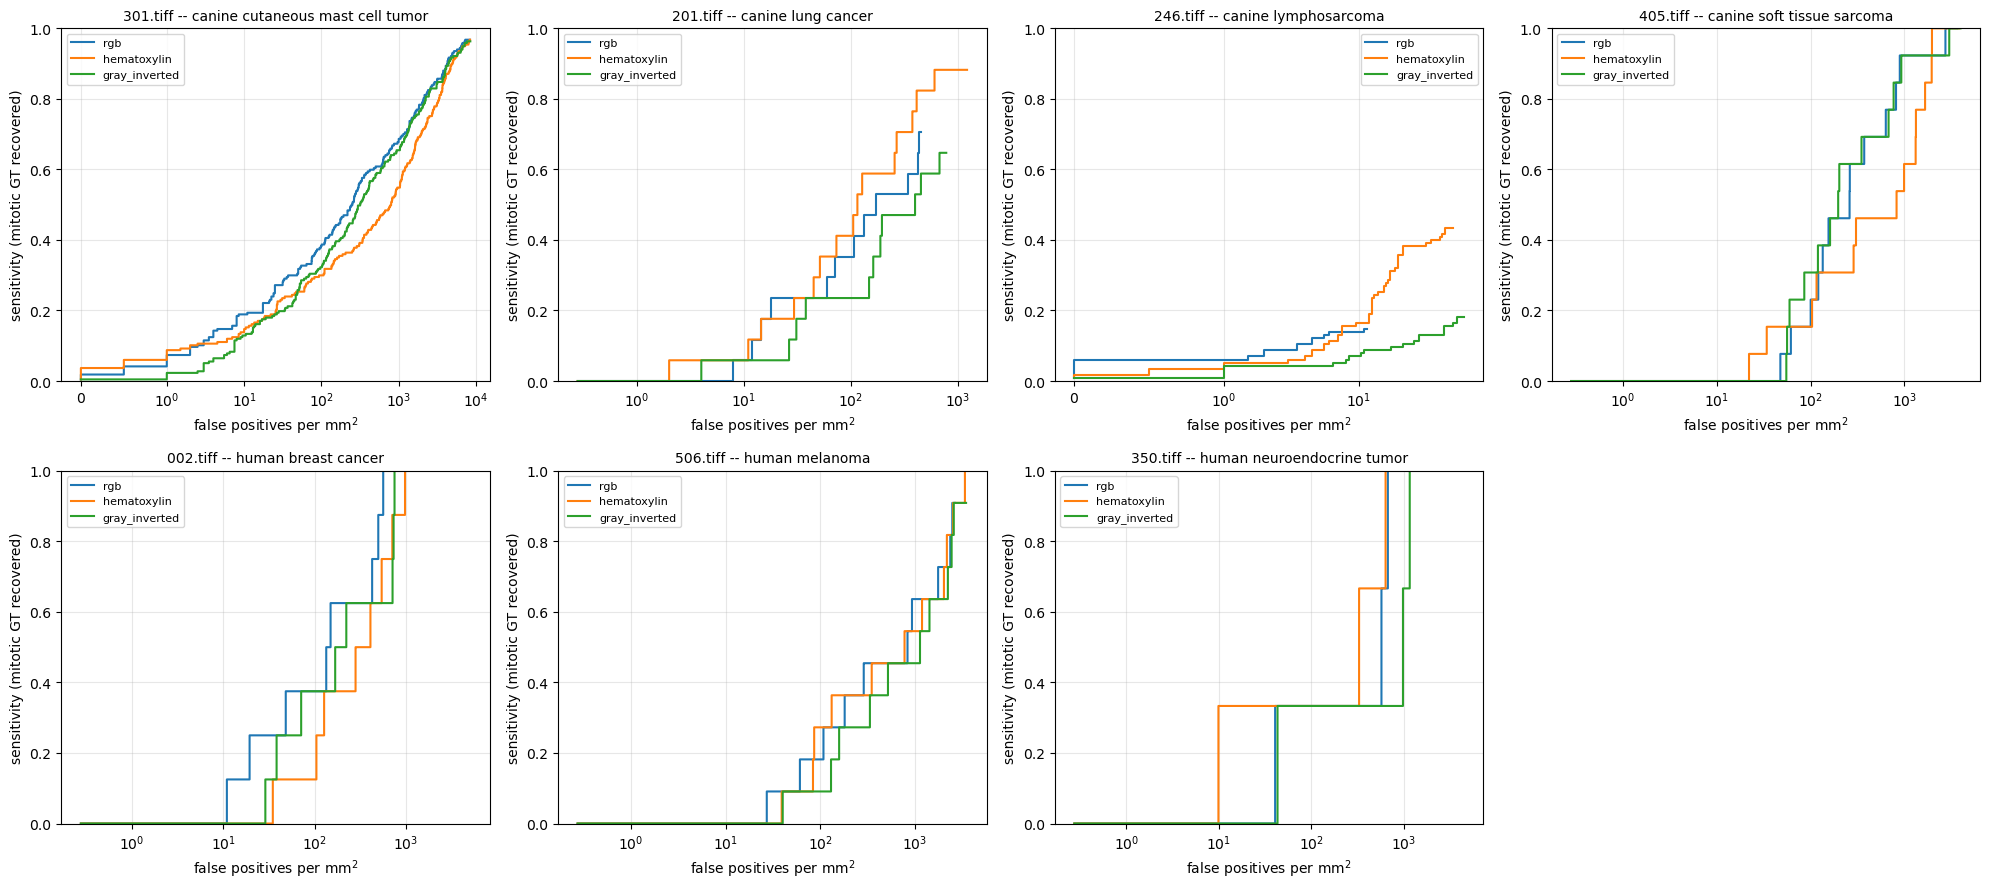

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, fn in zip(axes.ravel(), results.keys()):
    curves = [
        ('rgb', *results[fn]['curve']),
        ('hematoxylin', *results_hem[fn]['curve']),
        ('gray_inverted', *results_gray[fn]['curve']),
    ]
    tumor = selection.loc[selection.file_name == fn, 'tumor_type'].iloc[0]
    viz.froc_plot(curves, ax=ax, title=f'{fn} -- {tumor}')
for ax in axes.ravel()[len(results):]:
    ax.axis('off')
fig.tight_layout(); plt.show()


### Per-domain comparison

Not a single blended number across all 7 domains -- that average lets one domain (in
particular 246.tiff, which alone holds 115 of the 372 evaluation mitoses across all
seven ROIs) dominate the picture without it being visible in the summary. Each row
below is one domain; `recall_at_k` and `lookalike_attraction_at_k` are the same
equal-budget quantities used everywhere else in this notebook, and
`discrimination_proxy = recall_at_k - lookalike_attraction_at_k` reads whether a
channel is actually separating mitoses from look-alikes or just attracting to both
similarly.


In [ ]:
import pandas as pd
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 60)
combined = pd.read_csv('results/fs_rot90_channel_comparison_metrics.csv')
combined = combined[combined.method == 'find_and_suppress']

per_domain = combined.pivot_table(index=['tumor_type', 'file_name'], columns='channel',
                                   values=['recall_at_k', 'lookalike_attraction_at_k'])
for chan in ['rgb', 'hematoxylin', 'gray_inverted']:
    per_domain['discrimination_proxy', chan] = (
        per_domain['recall_at_k', chan] - per_domain['lookalike_attraction_at_k', chan])
per_domain = per_domain[['recall_at_k', 'discrimination_proxy', 'lookalike_attraction_at_k']].round(4)
per_domain


                                             recall_at_k                     discrimination_proxy                           lookalike_attraction_at_k                    
channel                                    gray_inverted hematoxylin     rgb                  rgb hematoxylin gray_inverted             gray_inverted hematoxylin     rgb
tumor_type                       file_name                                                                                                                               
canine cutaneous mast cell tumor 301.tiff         0.3041      0.2903  0.3318               0.1942      0.1894        0.2032                    0.1009      0.1009  0.1376
canine lung cancer               201.tiff         0.0588      0.0588  0.0588              -0.0024     -0.0432        0.0384                    0.0204      0.1020  0.0612
canine lymphosarcoma             246.tiff         0.1565      0.4000  0.1478               0.1234      0.3431        0.0996                    0.0569 

In [ ]:
def _winner(row, metric):
    vals = {c: row[(metric, c)] for c in ['rgb', 'hematoxylin', 'gray_inverted']}
    best = max(vals.values())
    winners = [c for c, v in vals.items() if v == best]
    return '/'.join(winners) if len(winners) > 1 else winners[0]

verdict = pd.DataFrame({
    'winner_by_discrimination': per_domain.apply(lambda r: _winner(r, 'discrimination_proxy'), axis=1),
    'winner_by_recall': per_domain.apply(lambda r: _winner(r, 'recall_at_k'), axis=1),
})
print(verdict.to_string())
print()
print('Sole-winner tally, discrimination_proxy (multi-way ties excluded):')
print(verdict['winner_by_discrimination'].value_counts().to_string())
print()
print('Sole-winner tally, recall_at_k (multi-way ties excluded):')
print(verdict['winner_by_recall'].value_counts().to_string())


                                                 winner_by_discrimination               winner_by_recall
tumor_type                       file_name                                                              
canine cutaneous mast cell tumor 301.tiff                   gray_inverted                            rgb
canine lung cancer               201.tiff                   gray_inverted  rgb/hematoxylin/gray_inverted
canine lymphosarcoma             246.tiff                     hematoxylin                    hematoxylin
canine soft tissue sarcoma       405.tiff               rgb/gray_inverted  rgb/hematoxylin/gray_inverted
human breast cancer              002.tiff   rgb/hematoxylin/gray_inverted  rgb/hematoxylin/gray_inverted
human melanoma                   506.tiff   rgb/hematoxylin/gray_inverted  rgb/hematoxylin/gray_inverted
human neuroendocrine tumor       350.tiff               rgb/gray_inverted  rgb/hematoxylin/gray_inverted

Sole-winner tally, discrimination_proxy (multi-way tie

**Reading the per-domain table.** Four of seven domains (405, 002, 506, 350.tiff) show
`recall_at_k = 0.000` for **every** channel -- no channel finds anything at this budget
on those, so they cannot argue for any channel and are excluded from the tallies below.
Of the three domains that show any signal at all:

- **301.tiff (mast cell tumor):** `rgb` has the best raw `recall_at_k` (0.332 vs 0.304
  gray / 0.290 hem), but `gray_inverted` has the best `discrimination_proxy` (0.203 vs
  0.194 rgb / 0.189 hem) -- `rgb` finds slightly more but also attracts to more
  look-alikes (0.138 vs 0.101/0.101).
- **201.tiff (lung cancer):** all three tie on raw recall (0.059), but `hematoxylin`'s
  look-alike attraction (0.102) is five times `gray_inverted`'s (0.020) for the same
  find -- pure cost, `gray_inverted` clearly better here.
- **246.tiff (lymphosarcoma):** `hematoxylin` wins outright and by a wide margin on
  both measures (recall 0.400 vs 0.157/0.148, discrimination 0.343 vs 0.100/0.123).
  This is also the domain with by far the most annotations (115 evaluation mitoses,
  next-largest is 218 seed-excluded on 301.tiff), so it's the single most
  statistically substantial data point in the whole comparison -- and it is also only
  one seed on one image, so "substantial" here means "less noisy than the others," not
  "settled."

**No channel wins uniformly, and the previous combined-mean ranking overstated
hematoxylin's case.** Sole-winner tally on the 3 non-degenerate domains:
`gray_inverted` wins 2/3 on discrimination_proxy (301, 201), `hematoxylin` wins 1/3
but by the largest margin of any single result here (246). `rgb` never uniquely wins
on discrimination_proxy but also never posts a *negative* one anywhere -- its worst
result (201.tiff, -0.002) rounds to roughly break-even, while `hematoxylin` posts
three separate negative discrimination results (201: -0.043, 405: -0.053, 350:
-0.063) -- domains where it finds nothing extra but attracts to look-alikes more than
the other two channels do.

**What this run actually supports:** not a single winner. `gray_inverted` is the
steadiest channel in this sample -- it never has the worst discrimination_proxy on
any domain and costs nothing extra in look-alike attraction on the zero-signal
domains. `hematoxylin`'s upside is real but concentrated entirely in one domain
(lymphosarcoma), and it has a visible, repeated cost (elevated look-alike attraction
with no recall gain) on three other domains. `rgb` is competitive without needing a
stain-deconvolution step, never actively worse, but never uniquely best either. With
only 3 of 7 domains showing any differentiating signal and each channel winning (or
losing) on a different one, this is not enough evidence to commit to one channel --
the next step is more seeds per image, weighted toward 246.tiff, 201.tiff, and
301.tiff specifically, since those are the only domains where channel choice was
visible at all here.
